# Harbor Tasks Analysis

Analysis of task complexity distribution and category diversity across all dataset versions in `harbor_tasks_8192_deduped/`.

In [1]:
import re
import tomllib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
TASKS_DIR = Path('../harbor_tasks_8192_deduped')

# Dataset version directories (task dirs live directly inside these)
DATASET_DIRS = [
    TASKS_DIR / 'harbor_4.5opus_tasks' / 'harbor_tasks_claude4.5_opus' / 'harbor_tasks_part2_2-1',
    TASKS_DIR / 'harbor_4.5opus_tasks' / 'harbor_tasks_claude4.5_opus' / 'harbor_tasks_part2_2-2',
    TASKS_DIR / 'harbor_4.5opus_tasks' / 'harbor_tasks_claude4.5_opus' / 'harbor_tasks_part2_2-3',
    TASKS_DIR / 'harbor_4.6opus_tasks_8192_part1-2' / 'harbor_tasks_8192',
    TASKS_DIR / 'harbor_4.6opus_tasks_8192_part1-2' / 'harbor_tasks_8192_part2',
    TASKS_DIR / 'harbor_4.8opus_tasks_v3',
]

## 1. Load Task Data

In [3]:
_STOPWORDS = {'the', 'and', 'for', 'that', 'with', 'this', 'from', 'are', 'have',
              'been', 'will', 'your', 'you', 'has', 'was', 'not', 'all', 'its',
              'can', 'but', 'which', 'any', 'also', 'should', 'into', 'now'}

_OUTCOME_PAT = re.compile(
    r'\bassert\b[^\n]*(subprocess|returncode|stdout|stderr|capture_output|\.read\b|content)',
    re.IGNORECASE,
)
_ASSERT_PAT = re.compile(r'\bassert\b')
_TOKEN_PAT   = re.compile(r'\b[a-zA-Z_][a-zA-Z0-9_]{2,}\b')

def compute_structural_score(test_code):
    """Fraction of assert lines that check outcomes (process/stdout/content) vs. state."""
    total = len(_ASSERT_PAT.findall(test_code))
    if not total:
        return 0.0
    outcome = len(_OUTCOME_PAT.findall(test_code))
    return outcome / total

def compute_desc_overlap(description, test_code):
    """Fraction of assert lines containing at least one keyword from the task description."""
    desc_kw = {t for t in _TOKEN_PAT.findall(description.lower()) if t not in _STOPWORDS}
    if not desc_kw:
        return 0.0
    assert_lines = re.findall(r'\bassert\b[^\n]*', test_code)
    if not assert_lines:
        return 0.0
    overlapping = sum(
        1 for ln in assert_lines
        if {t for t in _TOKEN_PAT.findall(ln.lower()) if t not in _STOPWORDS} & desc_kw
    )
    return overlapping / len(assert_lines)

In [4]:
VERSION_LABELS = {
    'harbor_4.5opus_tasks':              'v1 (4.5 opus)',
    'harbor_4.6opus_tasks_8192_part1-2': 'v2 (4.6 opus)',
    'harbor_4.8opus_tasks_v3':           'v3 (4.8 opus)',
}

def get_version_label(dataset_dir):
    for key, label in VERSION_LABELS.items():
        if key in str(dataset_dir):
            return label
    return 'unknown'

def load_tasks(dataset_dirs, max_per_dir=None):
    rows = []
    seen = set()
    for dataset_dir in dataset_dirs:
        if not dataset_dir.exists():
            continue
        version = get_version_label(dataset_dir)
        count = 0
        for task_dir in sorted(dataset_dir.iterdir()):
            if not task_dir.is_dir() or not task_dir.name.startswith('task_'):
                continue
            if task_dir.name in seen:
                continue
            seen.add(task_dir.name)

            toml_path = task_dir / 'task.toml'
            instruction_path = task_dir / 'instruction.md'
            test_path = task_dir / 'tests' / 'test_final_state.py'

            if not toml_path.exists() or not instruction_path.exists():
                continue

            with open(toml_path, 'rb') as f:
                meta = tomllib.load(f).get('metadata', {})

            description = instruction_path.read_text(errors='replace')
            test_code = test_path.read_text(errors='replace') if test_path.exists() else ''

            rows.append({
                'task_id':          task_dir.name,
                'version':          version,
                'difficulty':       meta.get('difficulty', 'unknown'),
                'category':         meta.get('category', 'unknown').lower().strip(),
                'description_len':  len(description),
                'num_test_funcs':   len(re.findall(r'def test_', test_code)),
                'num_asserts':      len(_ASSERT_PAT.findall(test_code)),
                'structural_score': compute_structural_score(test_code),
                'desc_overlap':     compute_desc_overlap(description, test_code),
            })
            count += 1
            if max_per_dir and count >= max_per_dir:
                break
    return pd.DataFrame(rows)

# Sample up to 500 tasks per directory for fast loading (~10s total)
df = load_tasks(DATASET_DIRS, max_per_dir=500)
print(f'Loaded {len(df):,} tasks')
print(df['difficulty'].value_counts().to_string())

Loaded 3,000 tasks
difficulty
medium    2171
easy       574
hard       255


## 2. Task Complexity Metrics Distribution

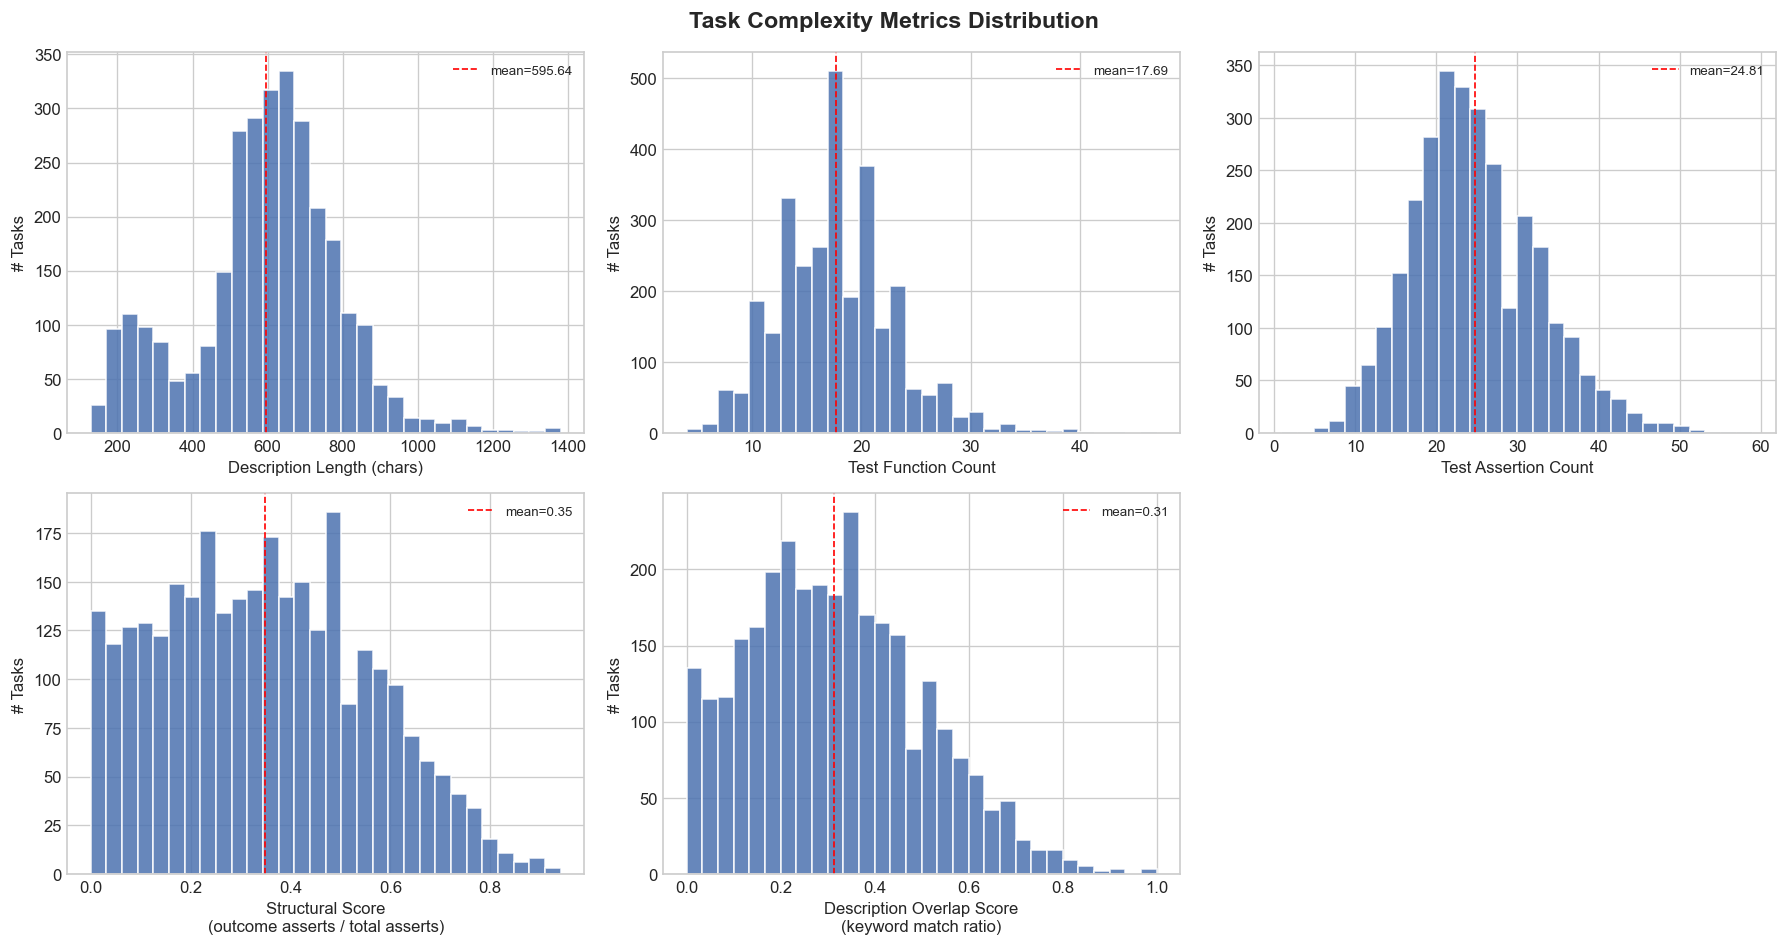

       description_len  num_test_funcs  num_asserts  structural_score  desc_overlap
count         3000.000        3000.000     3000.000          3000.000      3000.000
mean           595.642          17.693       24.814             0.348         0.314
std            195.592           5.225        7.719             0.206         0.184
min            129.000           4.000        1.000             0.000         0.000
25%            506.000          14.000       20.000             0.182         0.176
50%            613.000          17.000       24.000             0.333         0.300
75%            713.000          21.000       30.000             0.500         0.435
max           1381.000          47.000       59.000             0.941         1.000


In [5]:
metrics = [
    ('description_len',  'Description Length (chars)'),
    ('num_test_funcs',   'Test Function Count'),
    ('num_asserts',      'Test Assertion Count'),
    ('structural_score', 'Structural Score\n(outcome asserts / total asserts)'),
    ('desc_overlap',     'Description Overlap Score\n(keyword match ratio)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Task Complexity Metrics Distribution', fontsize=14, fontweight='bold')

for ax, (col, label) in zip(axes.flat, metrics):
    ax.hist(df[col], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1,
               label=f'mean={df[col].mean():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('# Tasks')
    ax.legend(fontsize=8)

# Hide unused subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

print(df[['description_len', 'num_test_funcs', 'num_asserts', 'structural_score', 'desc_overlap']]
      .describe().round(3).to_string())

## 3. Task Categories (multi-label)

In [6]:
CATEGORY_TO_DOMAIN = {
    # file operations
    'file and directory management':         'file_operations',
    'symbolic link management':              'file_operations',
    'file permissions and ownership':        'file_operations',
    'complex permissions management':        'file_operations',
    'archive and compression':               'file_operations',
    'backup and archiving':                  'file_operations',
    'file compression and extraction':       'file_operations',
    'corrupt archive recovery':              'file_operations',
    'file search and grep':                  'file_operations',
    'text processing and manipulation':      'file_operations',
    'text processing':                       'file_operations',
    'log analysis':                          'file_operations',
    'log parsing and analysis':              'file_operations',
    'regex-based log filtering':             'file_operations',
    'awk and sed text processing':           'file_operations',
    'cut and paste column manipulation':     'file_operations',
    'sort and uniq frequency counting':      'file_operations',
    'find and xargs batch file operations':  'file_operations',
    'text diffing and patch application':    'file_operations',
    'text encoding conversions':             'file_operations',
    'checksum verification':                 'file_operations',
    'binary data format parsing':            'file_operations',
    # system administration
    'dev environment setup':                 'system_administration',
    'running old code':                      'system_administration',
    'launch a webserver':                    'system_administration',
    'firewall configuration':                'system_administration',
    'cron job management':                   'system_administration',
    'cron and systemd timer authoring (user)': 'system_administration',
    'scheduled tasks and cron jobs':         'system_administration',
    'process management':                    'system_administration',
    'service management':                    'system_administration',
    'service configuration':                 'system_administration',
    'network configuration':                 'system_administration',
    'network diagnostics':                   'system_administration',
    'dns and hostname resolution':           'system_administration',
    'user and group management':             'system_administration',
    'user and permission management':        'system_administration',
    'disk and storage management':           'system_administration',
    'disk usage analysis':                   'system_administration',
    'environment variables and shell config': 'system_administration',
    'environment variable and dotenv management': 'system_administration',
    'environment configuration':             'system_administration',
    'package management':                    'system_administration',
    'pip package environment management':    'system_administration',
    'python virtual environment setup with venv': 'system_administration',
    'ssh configuration':                     'system_administration',
    'ssh keypair generation and management': 'system_administration',
    'docker container management':           'system_administration',
    'container management':                  'system_administration',
    'time zone and locale configuration':    'system_administration',
    'system monitoring and diagnostics':     'system_administration',
    'shell scripting automation':            'system_administration',
    # software engineering
    'makefile authoring and task automation': 'software_engineering',
    'semantic version bumping and changelogs': 'software_engineering',
    'git operations':                        'software_engineering',
    'git repository operations':             'software_engineering',
    'git submodule management':              'software_engineering',
    'ci/cd pipeline configuration':          'software_engineering',
    'api design and implementation':         'software_engineering',
    'api testing and curl operations':       'software_engineering',
    'headless browser data scraping':        'software_engineering',
    'refactoring':                           'software_engineering',
    'testing and tdd':                       'software_engineering',
    'dependency management':                 'software_engineering',
    'build systems':                         'software_engineering',
    'code generation':                       'software_engineering',
    'markdown documentation generation and linting': 'software_engineering',
    'remote file synchronization':           'software_engineering',
    # debugging
    'debugging':                             'debugging',
    'error diagnosis and fixing':            'debugging',
    'performance optimization':              'debugging',
    'memory and resource profiling':         'debugging',
    'distributed system debugging':          'debugging',
    'stripped elf binary reverse engineering': 'debugging',
    # data processing
    'data pipeline with error recovery':     'data_processing',
    'data transformation':                   'data_processing',
    'etl pipeline':                          'data_processing',
    'csv and tsv processing':                'data_processing',
    'csv/json data manipulation':            'data_processing',
    'json and yaml manipulation':            'data_processing',
    'json schema validation and jq processing': 'data_processing',
    'yaml and toml configuration editing':   'data_processing',
    'ini configuration parsing':             'data_processing',
    'xml processing':                        'data_processing',
    # data querying
    'sqlite database operations via cli':    'data_querying',
    'database operations':                   'data_querying',
    'database administration':               'data_querying',
    'database migration with data validation': 'data_querying',
    'sql query writing':                     'data_querying',
    # security
    'cryptography and certificates':         'security',
    'certificate management':                'security',
    'gpg file encryption and signature verification': 'security',
    'security hardening':                    'security',
    'security scanning':                     'security',
    'authentication configuration':          'security',
    'exploiting/fixing security vulnerabilities': 'security',
    # scientific computing
    'numerical computing':                   'scientific_computing',
    'simulation':                            'scientific_computing',
    'optimization solvers':                  'scientific_computing',
    'data analysis and visualization':       'scientific_computing',
    'machine learning pipeline':             'scientific_computing',
    'statistical analysis':                  'scientific_computing',
}

df['domain'] = df['category'].map(CATEGORY_TO_DOMAIN).fillna('other')

unmapped = df[df['domain'] == 'other']['category'].value_counts()
if len(unmapped) > 0:
    print('Categories mapped to "other" (check if any need explicit mapping):')
    print(unmapped.to_string())
else:
    print('All categories mapped successfully.')

All categories mapped successfully.


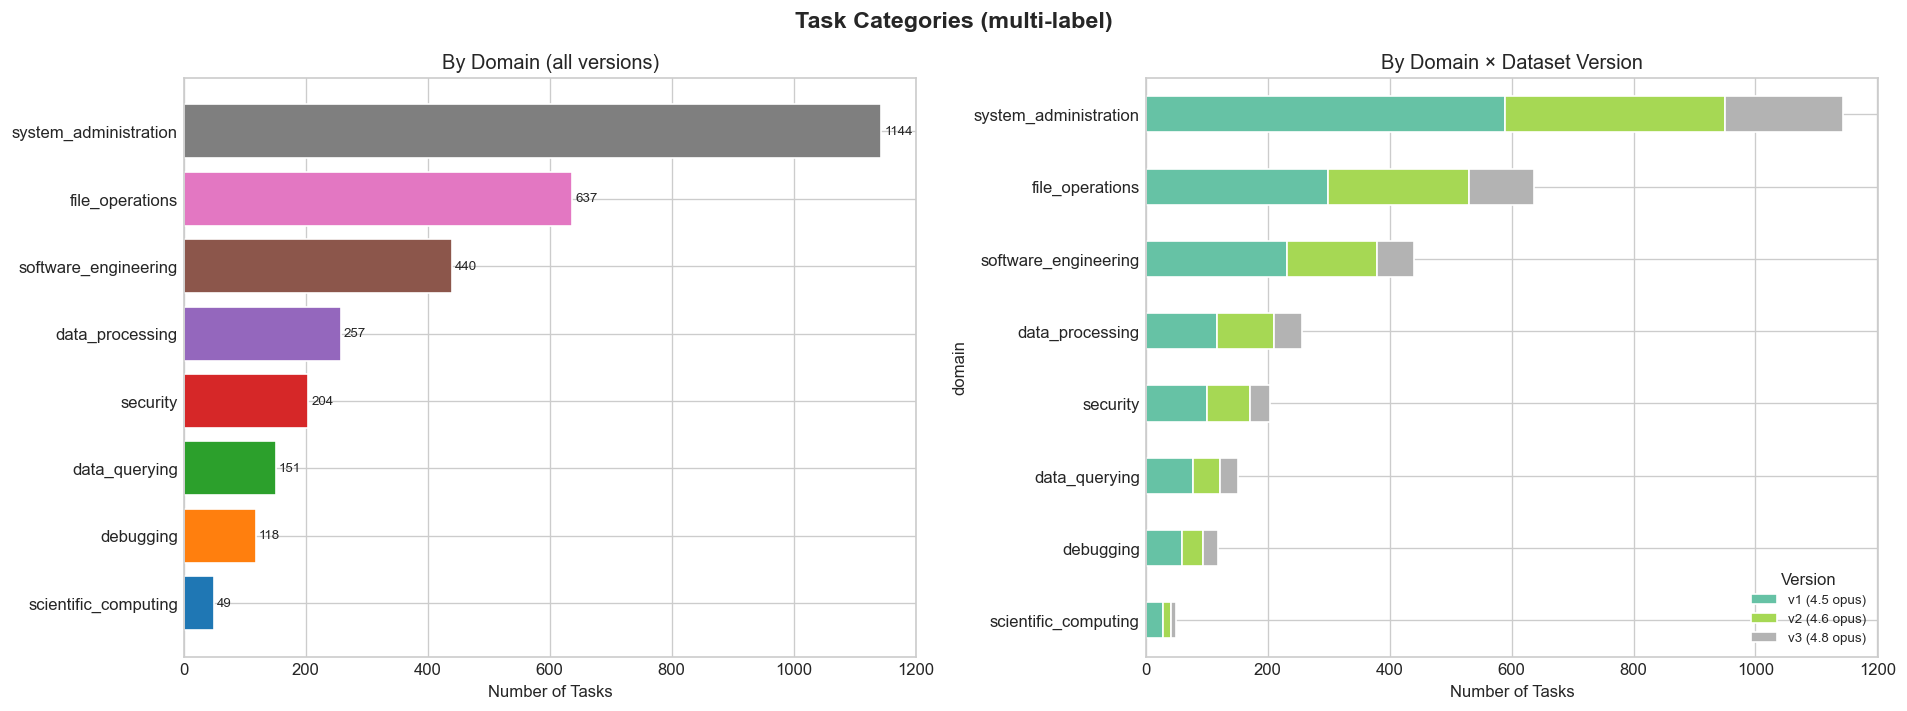


Total tasks: 3,000
Unique domains: 8
Unique categories: 64


In [7]:
domain_counts = df['domain'].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Task Categories (multi-label)', fontsize=14, fontweight='bold')

# Left: domain-level bar chart
colors = plt.cm.tab10.colors
axes[0].barh(domain_counts.index, domain_counts.values, color=colors[:len(domain_counts)], edgecolor='white')
axes[0].set_xlabel('Number of Tasks')
axes[0].set_title('By Domain (all versions)')
for i, v in enumerate(domain_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=8)

# Right: stacked bar by dataset version
pivot = df.pivot_table(index='domain', columns='version', aggfunc='size', fill_value=0)
pivot = pivot.reindex(domain_counts.index)
pivot.plot(kind='barh', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_xlabel('Number of Tasks')
axes[1].set_title('By Domain × Dataset Version')
axes[1].legend(title='Version', fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nTotal tasks: {len(df):,}')
print(f'Unique domains: {df["domain"].nunique()}')
print(f'Unique categories: {df["category"].nunique()}')